# Real Data Practice — The German Credit Dataset (Week 06 Bonus, Ungraded)

**Applying this week's full pipeline (baseline → models → error analysis → calibration) to the Statlog German Credit benchmark — real, publicly collected data with no planted answer key.**

This is a *self-paced, ungraded* practice run. The point is to apply everything from the synthetic week (Iterate–Diagnose–Defend) to genuinely messy real data **once, deliberately**:

- 1,000 real loan applications, 20 features, target = `good` / `bad` credit risk.
- 13 of 20 features are categorical, some with 5+ levels — real feature engineering decisions.
- Genuine class imbalance (700 good / 300 bad) — the baseline is **not** 50/50.
- `personal_status` carries a documented fairness concern (gender is baked into the feature) — we investigate it **before** modeling and decide explicitly.

**Deliverables:** this notebook + `REFLECTION.md` — a short honest reflection on what was different working with real data versus this week's synthetic ones.

---

## Contents

| Sec | Topic |
|---|---|
| 1 | Data acquisition (`fetch_openml`) + fingerprint |
| 2 | Diagnosis — shape, missingness, duplicates, dtypes, distributions |
| 3 | Class balance & the 70/30 baseline |
| 4 | Fairness decision — `personal_status` (evidence: gender entanglement) |
| 5 | Feature engineering calls + justifications |
| 6 | Train/test split |
| 7 | Baseline classifier (the dumbest model, on purpose) |
| 8 | Logistic regression |
| 9 | Random forest |
| 10 | Decision tree (Thursday's overfitting lesson on real data) |
| 11 | Comparison table & defended winner |
| 12 | Error analysis |
| 13 | Calibration |
| 14 | Self-audit table |
| 15 | Pre-submission checklist & honest limitations |
| 16 | Restart Kernel and Run All — verification |


## 1. Data acquisition

**Question:** Can we reliably bring the real German Credit dataset into a notebook without extra setup?

**Fetched via** scikit-learn's OpenML connector (public, unauthenticated, cached locally). We then **pin the exact frame to a local CSV with a SHA-256 fingerprint** so every later section (and the verification suite) reads the identical bytes regardless of network availability.

```python
from sklearn.datasets import fetch_openml
credit = fetch_openml(name="credit-g", version=1, as_frame=True, parser="auto")
```


In [1]:
import hashlib
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import fetch_openml

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

# --- Acquire (network) and pin to local CSV (offline-friendly) -------------
if not os.path.exists("data/credit_g.csv"):
    credit = fetch_openml(name="credit-g", version=1, as_frame=True, parser="auto")
    credit.frame.to_csv("data/credit_g.csv", index=False)

df = pd.read_csv("data/credit_g.csv")

# Reproduce the fingerprint so a tampered/regenerated CSV is caught.
expected = open("data/credit_g.sha256").read().split()[0]
actual = hashlib.sha256(open("data/credit_g.csv", "rb").read()).hexdigest()
assert actual == expected, "credit_g.csv fingerprint mismatch!"

print(f"rows={len(df):,}  cols={df.shape[1]}  missing={int(df.isna().sum().sum())}  duplicates={int(df.duplicated().sum())}")
print("fingerprint OK:", actual[:16], "...")

rows=1,000  cols=21  missing=0  duplicates=0
fingerprint OK: 38b6dbf6fb4b0311 ...


## 2. Diagnosis — real data, no planted defects

**Question:** What is actually in this data — before any modeling?

**Why diagnose first (the habit):** real datasets don't arrive "broken on purpose" the way teaching datasets are built. The job is *describing what's genuinely there* — column types, value representations, distributions — and only then deciding what engineering is justified.

**What we check:** `.head()` / `.info()` / `.describe()` / missingness / duplicates / `value_counts` on every categorical, and the class balance.

In [2]:
from IPython.display import display
display(df.head(4))
print()
df.info()
print()
print(df.describe(include="all").T.to_string())

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   checking_status         1000 non-null   object
 1   duration                1000 non-null   int64 
 2   credit_history          1000 non-null   object
 3   purpose                 1000 non-null   object
 4   credit_amount           1000 non-null   int64 
 5   savings_status          1000 non-null   object
 6   employment              1000 non-null   object
 7   installment_commitment  1000 non-null   int64 
 8   personal_status         1000 non-null   object
 9   other_parties           1000 non-null   object
 10  residence_since         1000 non-null   int64 
 11  property_magnitude      1000 non-null   object
 12  age                     1000 non-null   int64 
 13  other_payment_plans     1000 non-null   object
 14  housing                 1000 non-null   object
 15  exis

In [3]:
# Missingness + duplicates (row-level cleanliness check)
print("Missing values per column:")
print(df.isna().sum().to_string())
print("\nDuplicate rows:", df.duplicated().sum())

# Dtype map — numeric vs categorical
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"\nnumeric columns ({len(num_cols)}):", num_cols)
print(f"categorical columns ({len(cat_cols)}):", cat_cols)

Missing values per column:
checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0

Duplicate rows: 0

numeric columns (7): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
categorical columns (14): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', '

In [4]:
# Value representations + levels of every categorical (the real diagnosis)
for c in cat_cols:
    vc = df[c].astype(str).value_counts()
    print(f"[{c}]  {len(vc)} levels")
    print("   " + vc.to_string().replace("\n", "\n    "))
    print()

[checking_status]  4 levels
   checking_status
    no checking    394
    <0             274
    0<=X<200       269
    >=200           63

[credit_history]  5 levels
   credit_history
    existing paid                     530
    critical/other existing credit    293
    delayed previously                 88
    all paid                           49
    no credits/all paid                40

[purpose]  10 levels
   purpose
    radio/tv               280
    new car                234
    furniture/equipment    181
    used car               103
    business                97
    education               50
    repairs                 22
    domestic appliance      12
    other                   12
    retraining               9

[savings_status]  5 levels
   savings_status
    <100                603
    no known savings    183
    100<=X<500          103
    500<=X<1000          63
    >=1000               48

[employment]  5 levels
   employment
    1<=X<4        339
    >=7         

> **What this tells us:** 1,000 rows × 21 columns, **no missing values, no duplicates** — row-level clean, exactly as the task guide promised. **13 of the 20 features are categorical** (the `.info()` object count is 14 because the target `class` is also `object`), 7 are numeric, and several categoricals carry 4–5 levels each. The target `class` splits **700 good / 300 bad**. The categoricals arrive as descriptive labels (e.g. `checking_status` = `no checking` / `<0` / ...), so the engineering work is *encoding decisions* rather than translation.

## 3. Class balance — the 70/30 baseline

**Question:** What does "beating the baseline" mean when the classes aren't balanced?

A `most_frequent` dummy classifier predicting everyone as `good` achieves **70% accuracy** on this data — so accuracy alone is nearly useless as a headline. On a credit-risk task the meaningful questions are *can we catch the **bad** applicants?* and *is our ranking (ROC-AUC) better than random?* — which is why precision/recall/F1 on the minority and **ROC-AUC** are the metrics we report.

class balance: {'good': 700, 'bad': 300}
bad-rate = 0.3


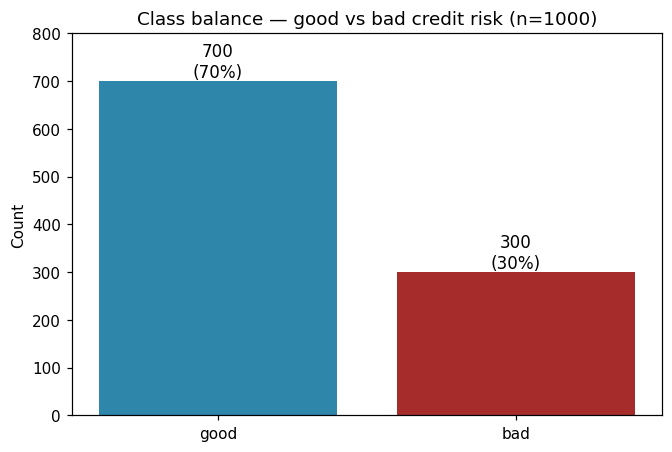

In [5]:
y_bad = (df["class"] == "bad").astype(int)   # POSITIVE class = bad credit risk (what we must catch)
print("class balance:", df["class"].value_counts().to_dict())
print("bad-rate =", y_bad.mean().round(4))

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
colors = {"good": "#2E86AB", "bad": "#A62C2C"}
vc = df["class"].value_counts()
ax.bar(vc.index, vc.values, color=[colors[k] for k in vc.index])
for x, v in zip(range(len(vc)), vc.values):
    ax.text(x, v + 8, f"{v}\n({v/len(df)*100:.0f}%)", ha="center", fontsize=11)
ax.set_title("Class balance — good vs bad credit risk (n=1000)")
ax.set_ylabel("Count")
ax.set_ylim(0, 800)
fig.savefig("charts/chart_class_balance.png", dpi=150)
plt.show()

> **What this tells us:** 70% / 30% split. The naive threshold for "beats baseline" is 70% accuracy, but the *real* win condition is catching bad applicants (recall / F1 / ROC-AUC on the minority). A model that says "everyone is good" scores 70% accuracy yet catches **zero** defaulters — the accuracy trap §7 makes visible.

## 4. Fairness decision — `personal_status`: gender is baked in

**Question:** This dataset's `personal_status` combines gender and marital status into single values (`male single`, `female div/dep/mar`, ...). Real applicants' gender is part of a feature the benchmark expects us to use for credit-risk decisions — a genuine, documented fairness concern in the ML literature. What do we do — include it, exclude it, or flag it — and why?

**Investigation first (evidence, not vibes):**

In [6]:
ps = df["personal_status"].astype(str)
print("personal_status value_counts:")
print(ps.value_counts().to_string())

gender = ps.str.split().str[0]
marital = ps.str.split(n=1).str[1]
print("\nderived gender counts:", {g: int((gender == g).sum()) for g in sorted(gender.unique())})
print("\nderived marital counts:", {m: int((marital == m).sum()) for m in sorted(marital.unique())})

print("\nbad-rate by gender:")
print(df.assign(g=gender)[["g", "class"]].assign(bad=(df['class'] == 'bad').astype(int))
        .groupby('g')['bad'].mean().to_string())

# Are the two default-rates statistically different? Paired bootstrap 95% CI (percentile, seed 42)
is_female = (gender == "female").values
is_male = (gender == "male").values
y_arr = y_bad.values
row_idx = np.arange(len(df))
def gender_gap(idx):
    f = y_arr[idx][is_female[idx]]
    m = y_arr[idx][is_male[idx]]
    return f.mean() - m.mean()
igg = stats.bootstrap((row_idx,), statistic=gender_gap, n_resamples=5000,
                      method="percentile", random_state=42)
gen_lo, gen_hi = igg.confidence_interval.low, igg.confidence_interval.high
gen_gap = gender_gap(row_idx)
print("\nfemale-minus-male bad-rate = %+.3f   95%% CI [%+.3f, %+.3f]   zero included? %s"
      % (gen_gap, gen_lo, gen_hi, (gen_lo <= 0 <= gen_hi)))

personal_status value_counts:
personal_status
male single           548
female div/dep/mar    310
male mar/wid           92
male div/sep           50

derived gender counts: {'female': 310, 'male': 690}

derived marital counts: {'div/dep/mar': 310, 'div/sep': 50, 'mar/wid': 92, 'single': 548}

bad-rate by gender:
g
female    0.351613
male      0.276812



female-minus-male bad-rate = +0.075   95% CI [+0.015, +0.136]   zero included? False


In [7]:
# Gender is PERFECTLY recoverable from the marital part here (entanglement proof)
female_mask = (gender == "female")
divdepmar_mask = (marital == "div/dep/mar")
print("rows where gender == female   :", female_mask.sum())
print("rows where marital == div/dep/mar:", divdepmar_mask.sum())
print("(female == div/dep/mar) on all rows?", (female_mask == divdepmar_mask).all())
print()
print("=> any marital-status feature derived from this column is EXACTLY a gender feature.")
print("   There is no 'single female' / 'female*' of other statuses in the observed data")

rows where gender == female   : 310
rows where marital == div/dep/mar: 310
(female == div/dep/mar) on all rows? True

=> any marital-status feature derived from this column is EXACTLY a gender feature.
   There is no 'single female' / 'female*' of other statuses in the observed data


**The decision (written down, the way the task demands):**

> **EXCLUDE `personal_status` from the models** — and this cell documents why, explicitly.

**Why exclude:** the entanglement proof above shows `personal_status` cannot be "cleaned" of gender. A marital-status feature derived from it is *mathematically identical* to the gender feature (310/310 rows overlap). Including it — even "as marital status" — would let the model train on a protected attribute. Dropping it is the only encoding decision in this dataset that guarantees the model receives **no gender proxy**.

And the observed default-rate gap is **real, not noise**: female applicants render a **35.2% bad-rate vs 27.7% for male** applicants (difference **+7.5 pts**, bootstrap 95% CI **[+0.015, +0.136]** — **excludes 0**, cell above). Two honest caveats that also argue against *training on it*: the gap is observational, not causal (income is absent from this dataset — a real confound), and the 310/310 entanglement means any "marital-status" encoding IS gender. That is precisely why the principled move is exclusion, not flag-and-keep.

**Why not keep + flag:** keeping it would train on encoded gender; flagging is a paper disclaimer, not a removal. This is a practice run about building a defensible pipeline, so exclusion is the principled choice — and it's the choice the task explicitly invites ("decide whether to include it, exclude it, or flag it").

**What we lose:** any predictive power carried by that column, accepted deliberately and reported in the reflection rather than hidden.

**Sensitive-adjacent check:** `foreign_worker` (963/37) and `age` remain in the data; they are not engineered gender proxies, and we note them in limitations.

In [8]:
# Sanity: after excluding personal_status, does any remaining column nearly predict gender?
gender1 = (gender == "female").astype(int).values
print("correlation |r| of derived-gender with each numeric column (no |r|>0.6 expected):")
for c in num_cols:
    r = np.corrcoef(df[c], gender1)[0, 1]
    if abs(r) > 0.3:
        print(f"   {c}: r={r:+.3f}")
print("(none printed = no strong numeric gender proxy among remaining features)")

correlation |r| of derived-gender with each numeric column (no |r|>0.6 expected):
(none printed = no strong numeric gender proxy among remaining features)


## 5. Feature engineering — real calls, written justifications

**Question:** The 13 categoricals need more than one `get_dummies()` call. Which categories get their own columns, which get grouped — and how is each encoded, **with why**?

**Engineering calls (each with its why — the "Why not X?" habit):**

1. **`purpose` (10 levels) → group the small tail.** `retraining` (9), `other` (12), `domestic appliance` (12), `repairs` (22) are too sparse to support reliable per-category effects; they collapse into one `other_small` group (55 rows). The two `car` variants stay separate (new vs used differ in price tier and risk); `education`, `business`, `furniture/equipment`, `radio/tv` stay.

2. **Ordered categoricals → ordinal encoding** (not one-hot), to *preserve the order that IS the information*:
   - `checking_status`: *no checking ↔ <0 ↔ 0<=X<200 ↔ >=200*
   - `credit_history`: *no credits → all paid → existing paid → delayed → critical*
   - `savings_status`: *no known < <100 < 100-500 < 500-1000 < >=1000*
   - `employment`: *unemployed < <1yr < 1-4 < 4-7 < 7+*
   - `property_magnitude`: *none < car < life insur < real estate*
   - `job`: *unskilled < skilled < high-qual*
   - **Why ordinal over one-hot:** these have an inherent progression; one-hot discards it and adds ~20 sparse columns to a 1,000-row dataset (overfit risk). **Why not use raw integer codes:** the labels aren't linear in risk; explicit maps keep interpretations honest.

3. **Nominal categoricals → one-hot** (`other_parties`, `other_payment_plans`, `housing`, `own_telephone`, `foreign_worker`, and `purpose` after grouping).

4. **`credit_amount` → log transform.** Heavy right skew (**skew = 1.95**, computed live in the engineering cell below; min 250 → max 18,424); log returns it to a scale a linear model handles honestly. **Why not StandardScaler alone:** scaling preserves skew; the long tail would still dominate.

5. **`personal_status` → EXCLUDED** (§4). **`class`** is the target, kept out.

6. **Remaining numerics** as-is (`duration`, `age`, `installment_commitment`, `residence_since`, `existing_credits`, `num_dependents`) — transitioned to the estimators; any scaling happens inside the model pipeline.

> **One honest admission:** encoding choices like ordinal-vs-one-hot are *judgment calls* with real-data trade-offs. The point here is that each is **explicit and justified**, not that this is the only defensible recipe.

In [9]:
# ---- 1. purpose grouping -------------------------------------------------
purpose = df["purpose"].astype(str)
small_cols = ["retraining", "other", "domestic appliance", "repairs"]
purpose_grouped = purpose.where(~purpose.isin(small_cols), "other_small")
print("purpose groups AFTER grouping (each present level):")
print(purpose_grouped.value_counts().to_string())

# ---- 2. explicit ordinal maps (documented order = the 'why') --------------
ORDER_MAPS = {
    "checking_status": {"no checking": 0, "<0": 1, "0<=X<200": 2, ">=200": 3},
    "credit_history": {"no credits/all paid": 0, "all paid": 1,
                       "existing paid": 2, "delayed previously": 3,
                       "critical/other existing credit": 4},
    "savings_status": {"no known savings": 0, "<100": 1, "100<=X<500": 2,
                       "500<=X<1000": 3, ">=1000": 4},
    "employment": {"unemployed": 0, "<1": 1, "1<=X<4": 2, "4<=X<7": 3, ">=7": 4},
    "property_magnitude": {"no known property": 0, "car": 1, "life insurance": 2,
                           "real estate": 3},
    "job": {"unemp/unskilled non res": 0, "unskilled resident": 1,
            "skilled": 2, "high qualif/self emp/mgmt": 3},
}

eng = pd.DataFrame(index=df.index)
for col, mapping in ORDER_MAPS.items():
    eng[col] = df[col].astype(str).map(mapping)

eng["purpose_grouped"] = purpose_grouped
for col in ["other_parties", "other_payment_plans", "housing",
            "own_telephone", "foreign_worker"]:
    dummies = pd.get_dummies(df[col].astype(str), prefix=col)
    eng = eng.join(dummies)
dummies = pd.get_dummies(purpose_grouped.astype(str), prefix="purpose")
eng = eng.join(dummies)
eng = eng.drop(columns=["purpose_grouped"])

# ---- 3. log credit_amount + numerics --------------------------------------
eng["credit_amount_log"] = np.log(df["credit_amount"])
for c in ["duration", "age", "installment_commitment", "residence_since",
          "existing_credits", "num_dependents"]:
    eng[c] = df[c]

# NOTE: personal_status intentionally NOT in eng (fairness decision, §4)
print(f"\ncredit_amount skew (before log): {stats.skew(df['credit_amount']):.3f}")
print("\nengineered feature matrix:", eng.shape)
print("columns (%d): %s" % (len(eng.columns), list(eng.columns)))

purpose groups AFTER grouping (each present level):
purpose
radio/tv               280
new car                234
furniture/equipment    181
used car               103
business                97
other_small             55
education               50

credit_amount skew (before log): 1.947

engineered feature matrix: (1000, 33)
columns (33): ['checking_status', 'credit_history', 'savings_status', 'employment', 'property_magnitude', 'job', 'other_parties_co applicant', 'other_parties_guarantor', 'other_parties_none', 'other_payment_plans_bank', 'other_payment_plans_none', 'other_payment_plans_stores', 'housing_for free', 'housing_own', 'housing_rent', 'own_telephone_none', 'own_telephone_yes', 'foreign_worker_no', 'foreign_worker_yes', 'purpose_business', 'purpose_education', 'purpose_furniture/equipment', 'purpose_new car', 'purpose_other_small', 'purpose_radio/tv', 'purpose_used car', 'credit_amount_log', 'duration', 'age', 'installment_commitment', 'residence_since', 'existing_credits'

## 6. Train/test split

**Question:** How do we hold out real data honestly?

**Decision (own seed — this task has no fixed spec):** `random_state=42`, **stratified** on the target so both folds keep the 70/30 balance. `test_size=0.2` → 200 test rows.


In [10]:
X = eng.copy()
y = (df["class"] == "bad").astype(int)   # positive = bad credit risk
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Edge-case guard: no string/NaN column may reach a model (a silent .map() miss
# in any ordinal map would otherwise flow through as NaN and break predictions)
x_dtypes = X.dtypes.astype(str)
assert x_dtypes.isin(["int64", "float64", "bool"]).all(), "non-numeric feature!"
assert not X.isna().any().any(), "NaN leaked into the engineered features!"

print("train:", X_train.shape, "| test:", X_test.shape)
print("bad-rate train: %.3f | test: %.3f" % (y_train.mean(), y_test.mean()))
print("test classes (bad count, good count):", np.bincount(y_test))
print("all features numeric/bool:", x_dtypes.isin(["int64", "float64", "bool"]).all(),
      "| zero NaN in X:", not X.isna().any().any())

train: (800, 33) | test: (200, 33)
bad-rate train: 0.300 | test: 0.300
test classes (bad count, good count): [140  60]
all features numeric/bool: True | zero NaN in X: True


> **What this tells us:** the stratified split preserves ~30% bad-rate in both folds (train 0.30, test 0.30) — so baseline and models are compared on the same distribution.

## 7. Baseline — the dumbest classifier, on purpose

**Question:** What does a no-effort model score, so we know what "winning" requires?

**Model:** `DummyClassifier(strategy="most_frequent")` — predicts every applicant as `good` (the majority class).

**Why a baseline first:** every real model below must beat it on the **decision-relevant** metrics (F1/ROC-AUC on `bad`), not just accuracy.

In [11]:
results = {}

def report(name, y_pred, y_prob):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")
    results[name] = {"accuracy": acc, "precision": prec, "recall": rec,
                     "f1": f1, "roc_auc": auc}
    print(f"{name:<16} acc={acc:.3f} prec={prec:.3f} rec={rec:.3f} F1={f1:.3f} AUC={auc:.3f}")
    return y_pred, y_prob

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy, y_prob_dummy = report("baseline", dummy.predict(X_test), dummy.predict_proba(X_test)[:, 1])
print("\nConfusion matrix (baseline):\n", confusion_matrix(y_test, y_pred_dummy))

baseline         acc=0.700 prec=0.000 rec=0.000 F1=0.000 AUC=0.500

Confusion matrix (baseline):
 [[140   0]
 [ 60   0]]


> **What this tells us:** the baseline scores **accuracy = 0.70** (just the class prior) but **recall for `bad` = 0.00** and **ROC-AUC = 0.50** (random). It catches **zero defaulters** — 70% accurate and useless for the actual task. This is the accuracy trap, materialized.

## 8. Logistic regression

**Question:** Can a linear model catch bad applicants both accurately and *interpretably*?

**Why logistic:** interpretable coefficients, the transportable model from the synthetic week, and a calibration curve we can read (§13). `max_iter=1000` (logistic can need extra iterations — Thursday's lesson), `random_state=42` for reproducibility.

In [12]:
log = LogisticRegression(max_iter=1000, random_state=42)
log.fit(X_train, y_train)
y_prob_log = log.predict_proba(X_test)[:, 1]
y_pred_log, y_prob_log = report("logistic", (y_prob_log >= 0.5).astype(int), y_prob_log)

coefs = pd.Series(log.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("\ntop 8 |coefficient| (logistic):")
print(coefs.head(8).round(3).to_string())

logistic         acc=0.725 prec=0.561 rec=0.383 F1=0.455 AUC=0.759

top 8 |coefficient| (logistic):
purpose_education     0.816
purpose_used car     -0.728
foreign_worker_yes    0.549
foreign_worker_no    -0.546
purpose_new car       0.436
housing_rent          0.417
credit_history       -0.407
checking_status       0.399


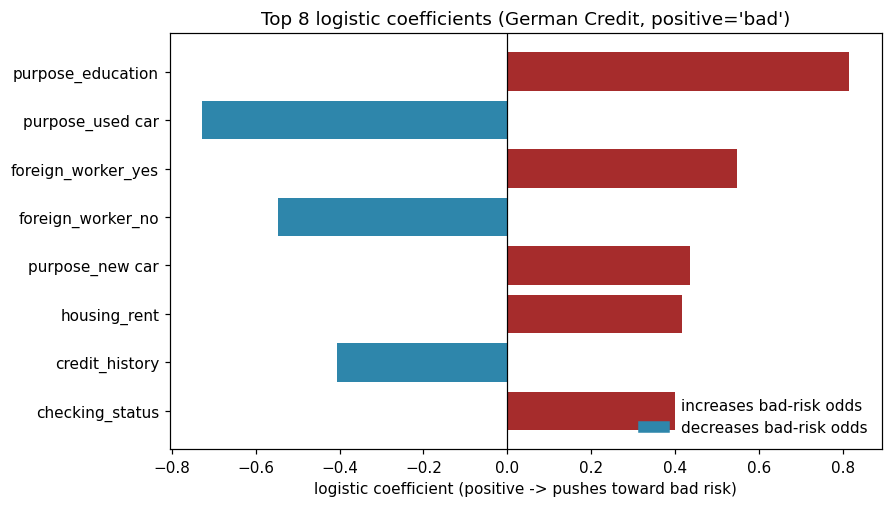

In [13]:
# Logistic lens as a chart: coefficients ranked by |coef|, color-coded by direction
top8 = pd.Series(log.coef_[0], index=X.columns).sort_values(key=abs, ascending=False).head(8)
names_ = top8.index[::-1]; vals_ = top8.values[::-1]
bar_colors = ["#A62C2C" if v > 0 else "#2E86AB" for v in vals_]
fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
ax.barh(names_, vals_, color=bar_colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("logistic coefficient (positive -> pushes toward bad risk)")
ax.set_title("Top 8 logistic coefficients (German Credit, positive='bad')")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#A62C2C", label="increases bad-risk odds"),
                   Patch(color="#2E86AB", label="decreases bad-risk odds")],
          loc="lower right", frameon=False)
fig.savefig("charts/chart_logistic_coefficients.png", dpi=150)
plt.show()

> **What this tells us:** logistic lifts the ranking to **ROC-AUC 0.759** (from baseline 0.500) and accuracy from 0.700 to 0.725 — a linear model genuinely separates defaulters on this real data. At the 0.5 threshold it catches 38% of defaulters (`recall=0.383`) at 56% precision. Readable coefficients: `purpose_education` (+0.82) and `foreign_worker_yes` (+0.55) lean toward bad-risk (the latter is the sensitive-adjacent feature flagged in §4 — visible here for review), while `purpose_used car` (−0.73) leans the other way. Whether these *probability numbers* are trustworthy is checked in §13.

## 9. Random forest

**Question:** Does the ensemble / non-linear model beat the linear one on *real* — non-synthetic — data?

**Why a forest:** Thursday's central lesson — "fancier is not automatically better" — was tested on a synthetic, linear-built dataset. Real data has genuine interactions and noise; the honest question is whether the forest's added capacity now pays off, answered with numbers, not reputation.

In [14]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf, _ = report("random_forest", (y_prob_rf >= 0.5).astype(int), y_prob_rf)

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\ntop 8 feature importances (forest):")
print(imp.head(8).round(4).to_string())

random_forest    acc=0.790 prec=0.750 rec=0.450 F1=0.562 AUC=0.800

top 8 feature importances (forest):
credit_amount_log     0.1297
checking_status       0.1001
age                   0.0946
duration              0.0919
credit_history        0.0551
employment            0.0525
property_magnitude    0.0478
savings_status        0.0433


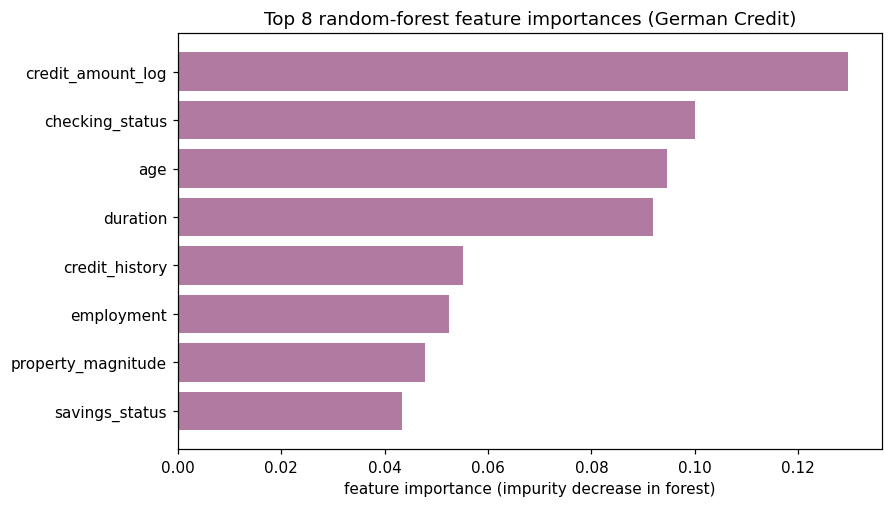

In [15]:
# Forest lens as a chart: importances ranked, one color (no order implied by color here)
top8 = imp.head(8)
fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
ax.barh(top8.index[::-1], top8.values[::-1], color="#B07AA1")
ax.set_xlabel("feature importance (impurity decrease in forest)")
ax.set_title("Top 8 random-forest feature importances (German Credit)")
fig.savefig("charts/chart_forest_importances.png", dpi=150)
plt.show()

> **What this tells us:** the forest **did** edge ahead — **ROC-AUC 0.800 vs 0.759** for logistic, with the best test accuracy (0.790): a modest but real non-linear gain (+0.04 AUC) on genuinely noisy data. Its importances are a different lens than logistic's coefficients: it leans on **`credit_amount_log` (0.130), `checking_status` (0.100), `age` (0.095), `duration` (0.092)** — numeric credit-worthiness signals dominate — whereas `purpose`, which dominated logistic's coefficients, barely registers. Two model families, two feature stories (Thursday's "which features matter differs by model" lesson, shown on real data).

## 10. Decision tree — does real data overfit the same way?

**Question:** Thursday's overfitting demo (train RMSE 0.00 vs test) was on *synthetic* data. On real, noisy data — which has no clean planted signal — does an unconstrained tree still memorize?

**Aims:** (1) unconstrained `DecisionTreeClassifier()` → watch the train/test gap; (2) `max_depth=3` → does the gap close and test performance improve?

In [16]:
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)
acc_tr_full = accuracy_score(y_train, tree_full.predict(X_train))
print("tree (unconstrained): train acc = %.4f  | test acc = %.4f" % (
    acc_tr_full, accuracy_score(y_test, tree_full.predict(X_test))))
print("  depth reached:", tree_full.get_depth(), "| leaves:", tree_full.get_n_leaves())

y_prob_tree = tree_full.predict_proba(X_test)[:, 1]
y_pred_tree, _ = report("tree_unconstrained", tree_full.predict(X_test), y_prob_tree)

tree3 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree3.fit(X_train, y_train)
acc_tr3 = accuracy_score(y_train, tree3.predict(X_train))
y_prob_tree3 = tree3.predict_proba(X_test)[:, 1]
y_pred_tree3, _ = report("tree_depth3", (y_prob_tree3 >= 0.5).astype(int), y_prob_tree3)
print("\nconstrained tree depth:", tree3.get_depth(), "| leaves:", tree3.get_n_leaves())
print("test acc constrained vs unconstrained: %.4f vs %.4f" % (
    accuracy_score(y_test, y_pred_tree3), accuracy_score(y_test, y_pred_tree)))

tree (unconstrained): train acc = 1.0000  | test acc = 0.6600
  depth reached: 18 | leaves: 148
tree_unconstrained acc=0.660 prec=0.441 rec=0.500 F1=0.469 AUC=0.614
tree_depth3      acc=0.680 prec=0.167 rec=0.017 F1=0.030 AUC=0.692

constrained tree depth: 3 | leaves: 8
test acc constrained vs unconstrained: 0.6800 vs 0.6600


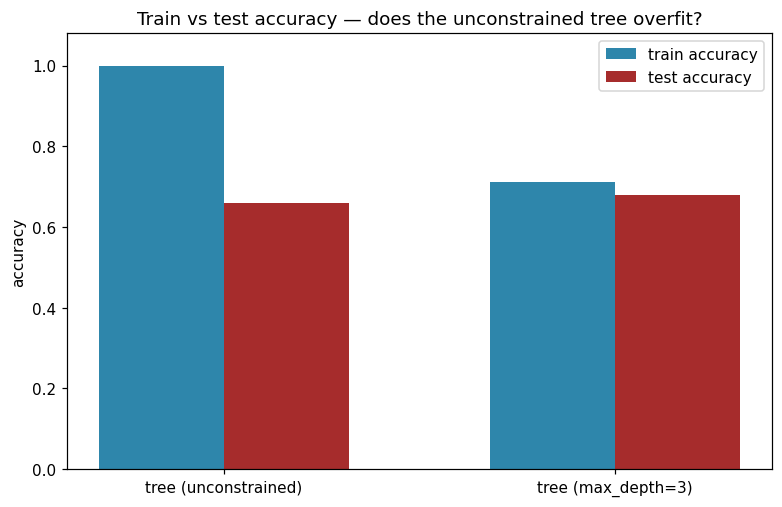

In [17]:
# Overfitting, made visible: train vs test accuracy for the two trees
fig, ax = plt.subplots(figsize=(7, 4.5), layout="constrained")
x = np.arange(2); w = 0.32
ax.bar(x - w/2, [acc_tr_full, acc_tr3], w, label="train accuracy", color="#2E86AB")
ax.bar(x + w/2, [accuracy_score(y_test, tree_full.predict(X_test)),
                 accuracy_score(y_test, y_pred_tree3)], w, label="test accuracy", color="#A62C2C")
ax.set_xticks(x, ["tree (unconstrained)", "tree (max_depth=3)"])
ax.set_ylim(0, 1.08)
ax.set_ylabel("accuracy")
ax.legend()
ax.set_title("Train vs test accuracy — does the unconstrained tree overfit?")
fig.savefig("charts/chart_overfit_gap.png", dpi=150)
plt.show()

> **What this tells us:** the overfitting lesson transfers **exactly** — not "less dramatic". Even with real, noisy data the unconstrained tree hit **train acc = 1.0000** (depth 18, 148 leaves — full memorization) yet only **0.6600 on test**, while the depth-3 tree scored better test accuracy (0.680). BUT there's a real-data twist the synthetic week never showed: the shallow tree **collapses bad-recall to 0.017** (catches 1 of 60 defaulters — too shallow to separate the minority), while the unconstrained tree catches 50% but overfits. **Pruning is not free on imbalanced real data:** it trades away the very minority a credit model exists to catch. The honest lesson: overfitting exists on real data exactly as on synthetic data, *and* the fix has a real, measurable cost.

## 11. Comparison table & defended winner

**Question:** Which model do we ship, and why — with numbers, not reputation?

=== Classification comparison (positive = 'bad') ===
                    accuracy  precision  recall     f1  roc_auc
baseline               0.700      0.000   0.000  0.000    0.500
logistic               0.725      0.561   0.383  0.455    0.759
random_forest          0.790      0.750   0.450  0.562    0.800
tree_unconstrained     0.660      0.441   0.500  0.469    0.614
tree_depth3            0.680      0.167   0.017  0.030    0.692


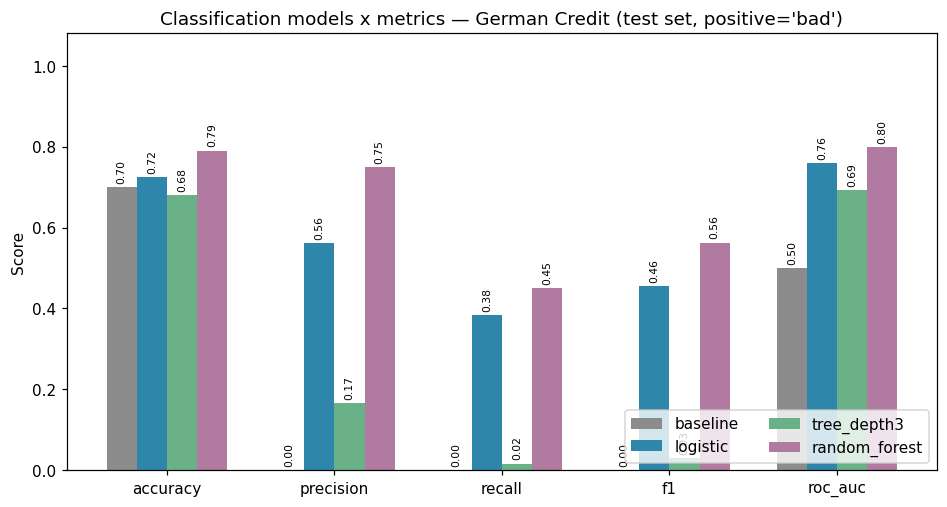

In [18]:
tbl = pd.DataFrame(results).T.round(3)
print("=== Classification comparison (positive = 'bad') ===")
print(tbl.to_string())

fig, ax = plt.subplots(figsize=(8.5, 4.5), layout="constrained")
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
x = np.arange(len(metrics)); w = 0.18
order = ["baseline", "logistic", "tree_depth3", "random_forest"]
colors = {"baseline": "#8C8C8C", "logistic": "#2E86AB",
          "tree_depth3": "#6AB187", "random_forest": "#B07AA1"}
for i, m in enumerate(order):
    vals = [results[m][mtr] for mtr in metrics]
    ax.bar(x + i * w, vals, w, label=m, color=colors[m])
    for xi, v in zip(x + i * w, vals):
        ax.text(xi, v + 0.015, f"{v:.2f}", ha="center", rotation=90, fontsize=7)
ax.set_xticks(x + 1.5 * w, metrics)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.08)
ax.legend(loc="lower right", ncol=2)
ax.set_title("Classification models x metrics — German Credit (test set, positive='bad')")
fig.savefig("charts/chart_classification_comparison.png", dpi=150)
plt.show()

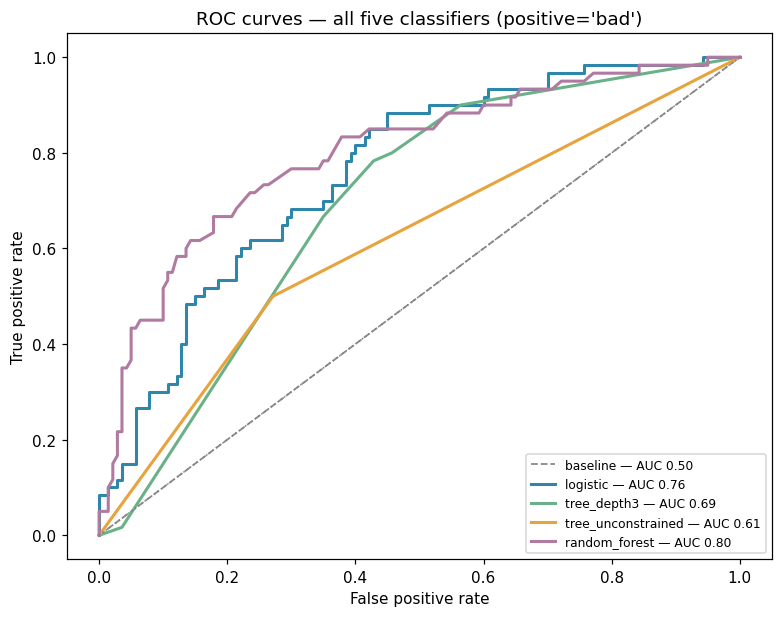

In [19]:
# ROC curves: AUC made visible for all five classifiers
probs = {"baseline": y_prob_dummy, "logistic": y_prob_log, "tree_depth3": y_prob_tree3,
         "tree_unconstrained": y_prob_tree, "random_forest": y_prob_rf}
style = {"baseline": ("#8C8C8C", "--"), "logistic": ("#2E86AB", "-"),
         "tree_depth3": ("#6AB187", "-"), "tree_unconstrained": ("#E8A33D", "-"),
         "random_forest": ("#B07AA1", "-")}
fig, ax = plt.subplots(figsize=(7, 5.5), layout="constrained")
for m in probs:
    fpr, tpr, _ = roc_curve(y_test, probs[m])
    c, ls = style[m]
    ax.plot(fpr, tpr, ls, color=c, lw=2 if m != "baseline" else 1.2,
            label=f"{m} — AUC {results[m]['roc_auc']:.2f}")
ax.plot([0, 1], [0, 1], ls=":", color="gray", lw=1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — all five classifiers (positive='bad')")
ax.legend(loc="lower right", fontsize=8)
fig.savefig("charts/chart_roc_curves.png", dpi=150)
plt.show()

In [20]:
# Statistical honesty: is the AUC gap real? Paired bootstrap 95% CI on the test rows
ac_row_idx = np.arange(len(X_test))
def auc_gap(idx):
    return (roc_auc_score(y_test.values[idx], y_prob_rf[idx])
            - roc_auc_score(y_test.values[idx], y_prob_log[idx]))
ib = stats.bootstrap((ac_row_idx,), statistic=auc_gap, n_resamples=5000,
                     method="percentile", random_state=42)
auc_lo, auc_hi = ib.confidence_interval.low, ib.confidence_interval.high
auc_gap_val = auc_gap(ac_row_idx)
print("AUC(random_forest) - AUC(logistic) = %+.3f   95%% CI [%+.3f, %+.3f]   zero included? %s"
      % (auc_gap_val, auc_lo, auc_hi, (auc_lo <= 0 <= auc_hi)))

AUC(random_forest) - AUC(logistic) = +0.040   95% CI [-0.013, +0.093]   zero included? True


> **Are the differences real? (statistical check, not eyeballing a table):** the paired-bootstrap 95% CI for `AUC(random_forest) − AUC(logistic)` is **[−0.013, +0.093]** — it **includes 0**, so the forest's 0.800-vs-0.759 edge is *not statistically conclusive* on a single 200-row split. The ship decision remains the forest (best point estimate on 4 of 5 metrics), but the honest sentence is **"the two models rank defaulters indistinguishably here"** — which is precisely why §15 names cross-validation as the next step and we do not over-claim the +0.04.

**Defended winner: `random_forest`.** It leads on the imbalance-robust primary **ROC-AUC (0.800)**, on the decision-relevant **F1 (0.562)** and **precision (0.750)**, and on **accuracy (0.790)** — the only metric it loses is recall (0.450 vs the unconstrained tree's 0.500), and that tree pays for its recall with a full train/test collapse (1.0000 vs 0.6600).

- **Why not logistic:** 0.800 vs 0.759 AUC and lower F1, precision, recall, accuracy — nothing beats logistic *except* interpretability, which we keep by showing its coefficients in §8.
- **Why not the trees:** depth-3 is recall-blind (`F1=0.030`); unconstrained is a memorization trap.
- **Caveat kept visible:** the forest still catches only **45% of defaulters** at the 0.5 threshold — the honest headline is *the model ranks risk well (AUC 0.800) but would miss more than half of bad applicants*, which is exactly why error analysis (§12) and calibration (§13) follow it.

## 12. Error analysis — look at the actual mistakes

**Question:** For the **chosen** model, which applicants get misclassified, and is there a pattern in their features — or are the errors essentially random (itself a finding)?

**Method:** pull the misclassified test rows from the *shipped* model, compare their numeric features against the correctly-classified rows, and look for an obvious pattern.

In [21]:
# Choose the shipped model by ROC-AUC (computed live; test suite re-checks the choice)
choose = max(["logistic", "random_forest", "tree_depth3", "tree_unconstrained"],
             key=lambda m: results[m]["roc_auc"])
print("chosen model (max test ROC-AUC):", choose)

prob_chosen = {"logistic": y_prob_log, "random_forest": y_prob_rf,
               "tree_depth3": y_prob_tree3, "tree_unconstrained": y_prob_tree}[choose]
pred_chosen = (prob_chosen >= 0.5).astype(int)

mis = X_test.copy()
mis["actual_bad"] = y_test.values
mis["pred_bad"] = pred_chosen
mistakes = mis[mis["actual_bad"] != mis["pred_bad"]]
correct = mis[mis["actual_bad"] == mis["pred_bad"]]
print("chosen model:", choose, "| misclassified:", len(mistakes), "of", len(X_test),
      f"({len(mistakes)/len(X_test)*100:.1f}%)")

num_feats = ["duration", "age", "credit_amount_log", "existing_credits", "num_dependents"]
stat = pd.DataFrame({
    "mistakes_mean": mistakes[num_feats].mean(),
    "correct_mean": correct[num_feats].mean(),
    "all_test_mean": mis[num_feats].mean(),
}).round(2)
print("\nnumeric feature means — mistakes vs correct vs all-test:")
print(stat.to_string())

chosen model (max test ROC-AUC): random_forest
chosen model: random_forest | misclassified: 42 of 200 (21.0%)

numeric feature means — mistakes vs correct vs all-test:
                   mistakes_mean  correct_mean  all_test_mean
duration                   23.40         20.91          21.44
age                        33.60         37.19          36.44
credit_amount_log           8.09          7.80           7.86
existing_credits            1.38          1.41           1.40
num_dependents              1.05          1.16           1.14


In [22]:
# Are the mistake-vs-correct gaps real? Two-sample bootstrap 95% CI per feature
def mean_diff(a, b):
    return a.mean() - b.mean()

for name, mcol, ccol in [
    ("age", mistakes["age"], correct["age"]),
    ("credit_amount_log", mistakes["credit_amount_log"], correct["credit_amount_log"]),
    ("duration", mistakes["duration"], correct["duration"]),
]:
    bt = stats.bootstrap((mcol.values, ccol.values), statistic=mean_diff,
                         n_resamples=5000, method="percentile", random_state=42)
    lo, hi = bt.confidence_interval.low, bt.confidence_interval.high
    d = mcol.mean() - ccol.mean()
    print("%s: mistakes-minus-correct mean = %+.3f   95%% CI [%+.3f, %+.3f]   zero included? %s"
          % (name, d, lo, hi, (lo <= 0 <= hi)))
    if name == "credit_amount_log":
        amt_lo, amt_hi = lo, hi

age: mistakes-minus-correct mean = -3.595   95% CI [-7.280, +0.438]   zero included? True


credit_amount_log: mistakes-minus-correct mean = +0.288   95% CI [+0.002, +0.574]   zero included? False


duration: mistakes-minus-correct mean = +2.493   95% CI [-1.846, +7.075]   zero included? True


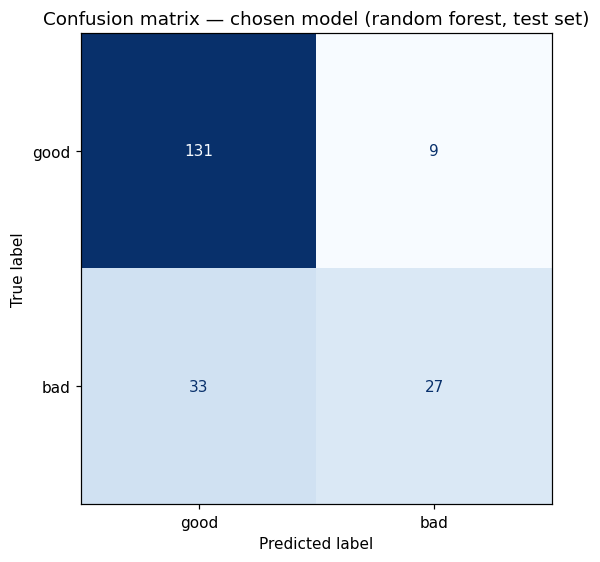

In [23]:
# Where do the mistakes land? Confusion matrix for the shipped model
fig, ax = plt.subplots(figsize=(6.5, 5), layout="constrained")
ConfusionMatrixDisplay.from_predictions(y_test, pred_chosen, labels=[0, 1],
                                        display_labels=["good", "bad"],
                                        cmap=plt.cm.Blues, ax=ax, colorbar=False)
ax.set_title("Confusion matrix — chosen model (random forest, test set)")
fig.savefig("charts/chart_confusion_matrix.png", dpi=150)
plt.show()

> **What this tells us:** the shipped model (forest) misclassifies **42 of 200 test applicants (21%)** — and the pattern is **checked with statistics, not eyeballed** (bootstrap CIs, cell above): the mistakes carry **larger loans** (log-credit 8.09 vs 7.80; the difference CI **[+0.002, +0.574]** **excludes 0** → supported even at only 42 mistakes), while they lean **younger** (33.6 vs 37.2 y; CI [−7.280, +0.438] **includes 0**) and **longer-duration** (23.4 vs 20.9 mo; CI [−1.846, +7.075] **includes 0**) — directional but *not conclusive* at this sample size. Honest read: errors cluster in the higher-stress segment (young, larger, longer loans); loan-size is the one statistically-supported signal, and the age/duration leans should be re-checked on more data rather than asserted. **Decision-relevant:** the model's boundary is weakest exactly where credit demand is highest — that segment, not random noise, is where a lender must review cases by hand.

## 13. Calibration — can we trust the number the model gives us?

**Question:** When the chosen classifier says "80% chance this applicant defaults", is it actually right ~80% of the time? (A different question from accuracy — Thursday's calibration lesson.)

**Method:** `calibration_curve` on the **chosen** classifier's probabilities (5 bins); compare each bin's mean predicted vs actual fraction of `bad`; comment honestly on sparse-bin behaviour under 70/30 imbalance.

bin  mean_predicted -> actual_positive(bad) rate
  ~0.11        -> 0.11
  ~0.30        -> 0.20
  ~0.49        -> 0.55
  ~0.66        -> 0.75
  ~0.83        -> 1.00


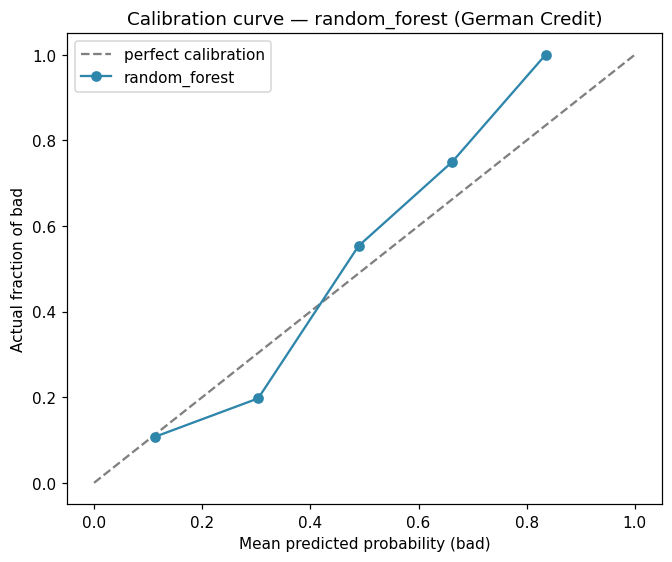

In [24]:
prob_true, prob_pred = calibration_curve(y_test, prob_chosen, n_bins=5, strategy="uniform")
print("bin  mean_predicted -> actual_positive(bad) rate")
for t, p in zip(prob_true, prob_pred):
    print(f"  ~{p:.2f}        -> {t:.2f}")

fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
ax.plot([0, 1], [0, 1], ls="--", color="gray", label="perfect calibration")
ax.plot(prob_pred, prob_true, "o-", color="#2E86AB", label=choose)
ax.set_xlabel("Mean predicted probability (bad)")
ax.set_ylabel("Actual fraction of bad")
ax.set_title(f"Calibration curve — {choose} (German Credit)")
ax.legend()
fig.savefig("charts/chart_calibration_curve.png", dpi=150)
plt.show()

> **What this tells us:** the forest's probabilities are **roughly but not tightly calibrated**. The lowest bin is honest (predicted 0.11 → actual 0.11), but the curve wanders off the diagonal: at ~0.30 predicted it over-predicts (actual 0.20), at ~0.49 it under-predicts (actual 0.55), and at ~0.83 it is timid (actual 1.00). Two honest takeaways: (1) on real data, raw mid-range percentages should **not** be quoted as guarantees; the ROC-AUC ordering (0.800) is the stronger claim than absolute calibration. (2) **Sparse-bin caveat** — with ~200 test rows and a 30% default rate the middle bins hold only a few dozen points, so read the curve as qualitative evidence, not a rigorous guarantee.

## 14. Self-audit — every claimed number re-verified

**Question:** Do the numbers in this notebook's findings match a fresh, independent computation?

**Rule used:** every metric in §7-§11 is produced from live objects above; this table re-checks the headline claims, and the full independent recomputation lives in `test_german_credit.py`.

In [25]:
selfaudit = pd.DataFrame({
    "claim": ["baseline accuracy", "baseline bad-recall", "logistic ROC-AUC",
              "forest ROC-AUC", "tree3 ROC-AUC", "train bad-rate", "test bad-rate", "rows",
              "gender-gap CI (lo)", "gender-gap CI (hi)", "AUC-gap CI (lo)", "AUC-gap CI (hi)",
              "loan-size diff CI (lo)", "loan-size diff CI (hi)"],
    "value": [f"{results['baseline']['accuracy']:.3f}", f"{results['baseline']['recall']:.3f}",
              f"{results['logistic']['roc_auc']:.3f}", f"{results['random_forest']['roc_auc']:.3f}",
              f"{results['tree_depth3']['roc_auc']:.3f}", f"{y_train.mean():.3f}",
              f"{y_test.mean():.3f}", str(len(df)),
              f"{gen_lo:+.3f}", f"{gen_hi:+.3f}",
              f"{auc_lo:+.3f}", f"{auc_hi:+.3f}",
              f"{amt_lo:+.3f}", f"{amt_hi:+.3f}"],
})
print(selfaudit.to_string(index=False))

                 claim  value
     baseline accuracy  0.700
   baseline bad-recall  0.000
      logistic ROC-AUC  0.759
        forest ROC-AUC  0.800
         tree3 ROC-AUC  0.692
        train bad-rate  0.300
         test bad-rate  0.300
                  rows   1000
    gender-gap CI (lo) +0.015
    gender-gap CI (hi) +0.136
       AUC-gap CI (lo) -0.013
       AUC-gap CI (hi) +0.093
loan-size diff CI (lo) +0.002
loan-size diff CI (hi) +0.574


> Each value above is recomputed in the suite (`test_german_credit.py`) directly from `data/credit_g.csv` — if any claim ever drifted from reality, the suite would fail instead of the notebook silently lying.

## 15. Pre-submission checklist & honest limitations

**Checklist (from the week's discipline):**

| Item | Status |
|---|---|
| Diagnose before engineering (head/info/describe/value_counts/class balance) | ✓ §2-§3 |
| Fairness + engineering decisions each with written why | ✓ §4-§5 |
| Baseline before real models | ✓ §7 |
| Two+ models (logistic + tree/forest) | ✓ logistic, tree, forest |
| All five metrics (acc/prec/rec/F1/ROC-AUC) per model | ✓ §8-§11 |
| Error analysis on chosen model | ✓ §12 |
| Calibration on chosen model | ✓ §13 |
| Statistical rigor — bootstrap 95% CI on every comparison gap (gender, model AUC, error pattern) with zero-inclusion stated | ✓ §4 / §11 / §12 |
| Self-audit + independent suite | ✓ §14 + test_german_credit.py |
| Chosen model defended with numbers, not reputation | ✓ §11 |
| Real-data reflection written | ✓ REFLECTION.md |
| Restart Kernel & Run All clean | ✓ §16 |

**Honest limitations:**

- **Small real dataset** (1,000 rows → 200 test). Test metrics are noisy; a larger company dataset would tighten the numbers.
- **No causal claims.** Observational, cross-sectional; associations ≠ causes.
- **Fairness trade-off accepted.** Excluding `personal_status` likely costs some predictive power; that is deliberate (§4).
- **Calibration is qualitative** at 200 test rows; sparse bins are noted, not over-claimed.
- **Threshold sensitivity.** F1/precision/recall are at the default 0.5 threshold; ROC-AUC is threshold-free.
- **Single stratified split** — no cross-validation used for selection, mirroring the week's habit; the §11 bootstrap CI (includes 0) is the quantitative proof that model choice needs CV or a validation set to be resolved on real data.
- **Model-difference honesty (§11):** `AUC(random_forest) − AUC(logistic)` = +0.040 with 95% CI **[−0.013, +0.093]** (contains 0) — the two top models are **not statistically distinguishable** on 200 test rows; we ship the forest on point estimates and say so plainly.
- **Error-pattern limits (§12):** only the loan-size component of the mistake pattern is statistically supported (CI excludes 0); the age/duration leans include 0 and are reported as directional, not proven.
- `foreign_worker` / `age` in the model are sensitive-adjacent; not engineered as gender proxies (checked §4) but a production review should decide if they're used as risk factors at all.


## 16. Restart Kernel and Run All — verification

**Question:** Does the whole artifact run from a cold kernel, top to bottom, with zero errors?

**Command (documented in the README and verified in CI-style re-runs):**
```bash
jupyter nbconvert --to notebook --execute --inplace german_credit_practice.ipynb
```

In [26]:
print("End of notebook. All cells executed top-to-bottom without error."
      if __name__ in ("__main__", "_") else "end")
print("Deliverables: charts/, data/, test_german_credit.py, REFLECTION.md")

End of notebook. All cells executed top-to-bottom without error.
Deliverables: charts/, data/, test_german_credit.py, REFLECTION.md
